In [8]:
import json
import pandas as pd

In [11]:
with open('../raw/novel_details.json','r',encoding='utf-8') as f:
    novel_details = json.load(f)
    
df = pd.DataFrame(novel_details)

In [3]:
df.shape

(408, 5)

In [4]:
df.head()

,title,link,description,genres,tags
0,A Certain Someone,https://www.novelupdates.com/series/a-certain-...,Sheng Wang moved into his ancestral home at Wh...,"[Comedy, Drama, Romance, School Life, Slice of...","[Absent Parents, Adapted to Drama, Adapted to ..."
1,Accidental Mark,https://www.novelupdates.com/series/accidental...,Pei Shaoze unintentionally heard about a novel...,"[Comedy, Romance, Slice of Life, Yaoi]","[Acting, Adapted to Drama CD, Alternate World,..."
2,After the Little Crybaby Enters the Nightmare ...,https://www.novelupdates.com/series/after-the-...,Chi Nan was the young man in one of the Top 10...,"[Action, Adventure, Horror, Mature, Mystery, S...","[Amnesia, Blind Protagonist, Calm Protagonist,..."
3,Being an Extra Actor in an Escape Game,https://www.novelupdates.com/series/being-an-e...,Xu Beijin is an extra in the game ‘Escape.’ Hi...,"[Action, Drama, Horror, Mystery, Romance, Sci-...","[Acting, Amnesia, Apathetic Protagonist, Apoca..."
4,Card Room,https://www.novelupdates.com/series/card-room/,Xiao Lou was killed in an accident and reborn ...,"[Action, Adventure, Comedy, Horror, Mature, My...","[Alternate World, Apocalypse, Businessmen, Cal..."


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 408 entries, 0 to 407
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   title        408 non-null    object
 1   link         408 non-null    object
 2   description  408 non-null    object
 3   genres       408 non-null    object
 4   tags         408 non-null    object
dtypes: object(5)
memory usage: 16.1+ KB


In [6]:
df['tags'].apply(len).describe()

count    408.000000
mean      31.031863
std       16.667922
min        4.000000
25%       19.000000
50%       29.000000
75%       39.000000
max      120.000000
Name: tags, dtype: float64

In [12]:
from itertools import chain
from collections import Counter

In [ ]:
tag_counts = Counter(list(chain.from_iterable(df['tags'])))

In [107]:
tag_counts.most_common(10)

[('Handsome Male Lead', 272),
 ('Strong Love Interests', 216),
 ('Love Interest Falls in Love First', 192),
 ('Calm Protagonist', 183),
 ('Power Couple', 168),
 ('Modern Day', 162),
 ('Clever Protagonist', 152),
 ('Devoted Love Interests', 146),
 ('Slow Romance', 134),
 ('Doting Love Interests', 130)]

In [126]:
top_tags = {tag:count for tag, count in tag_counts.items() if count > 10}

In [117]:
top_tags.__len__()

305

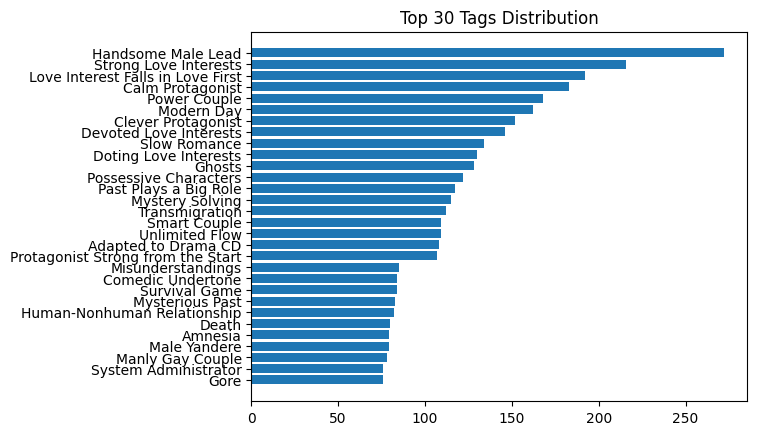

In [127]:
import matplotlib.pyplot as plt

# plt.figure(figsize=(8,10))
top_tags = pd.DataFrame(top_tags.items(), columns=['tag', 'count'])
top_tags = top_tags.sort_values('count', ascending=False)
plt.barh(top_tags.iloc[:30]['tag'], top_tags.iloc[:30]['count'])
plt.gca().invert_yaxis()
plt.title("Top 30 Tags Distribution")
plt.show()

In [128]:
df['filtered_tags'] = df['tags'].apply(lambda x: [tag for tag in x if tag in set(top_tags['tag'])])

In [135]:
df['filtered_tags'].apply(len).describe()

count    408.000000
mean      26.710784
std       13.408153
min        2.000000
25%       17.000000
50%       25.000000
75%       34.000000
max       79.000000
Name: filtered_tags, dtype: float64

In [134]:
unrealted_tags = ['Adapted to Drama CD','Adapted to Manhua','Adapted to Drama','Adapted to Anime','Adapted to Manhwa','Multiple POV','Unreliable Narrator','Cute Story',]
df['filtered_tags'] = df['filtered_tags'].apply(lambda x: [tag for tag in x if tag not in unrealted_tags])

In [ ]:
sorted({tag for tag in top_tags['tag'] if '*' in tag})

In [ ]:
# blacklist_tags = ['R*pe','R*pe Victim Becomes Lover','S*xual Abuse']
# clean_df = df[~df['tags'].apply(lambda x: any(tag in x for tag in blacklist_tags))]

In [147]:
df.drop(columns=['tags'], inplace=True)

In [ ]:
df.to_json('../processed/novel_details_cleaned.json',orient='records',force_ascii=False,indent=2)